<a href="https://colab.research.google.com/github/Jayasubharavi/aiml/blob/main/Logistic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np

In [3]:
df = pd.read_csv("carprices.csv")


In [4]:
df.columns = df.columns.str.strip()

In [5]:
print("Columns:", df.columns)
print(df.head())


Columns: Index(['Mileage', 'Age(yrs)', 'Sell Price($)'], dtype='object')
   Mileage  Age(yrs)  Sell Price($)
0    69000         6          18000
1    35000         3          34000
2    57000         5          26100
3    22500         2          40000
4    46000         4          31500


In [6]:
df['Price_Class'] = (df['Sell Price($)'] > 25000).astype(int)


In [7]:
X = df[['Mileage', 'Age(yrs)']]
y = df['Price_Class']


In [8]:
model = LogisticRegression()
model.fit(X, y)

LogisticRegression()

In [9]:
y_pred = model.predict(X)


In [10]:
print("Accuracy:", accuracy_score(y, y_pred))


Accuracy: 1.0


In [11]:
print("Confusion Matrix:")
print(confusion_matrix(y, y_pred))

Confusion Matrix:
[[ 9  0]
 [ 0 11]]


In [12]:
print("Prediction:", model.predict([[30000, 3]]))

Prediction: [1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [15]:
X_graph = df[['Mileage']]
y_graph = df['Price_Class']


In [16]:
graph_model = LogisticRegression()
graph_model.fit(X_graph, y_graph)


LogisticRegression()

In [20]:
x_test = np.linspace(df['Mileage'].min(), df['Mileage'].max(), 100).reshape(-1, 1)

In [21]:
y_prob = graph_model.predict_proba(x_test)[:, 1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


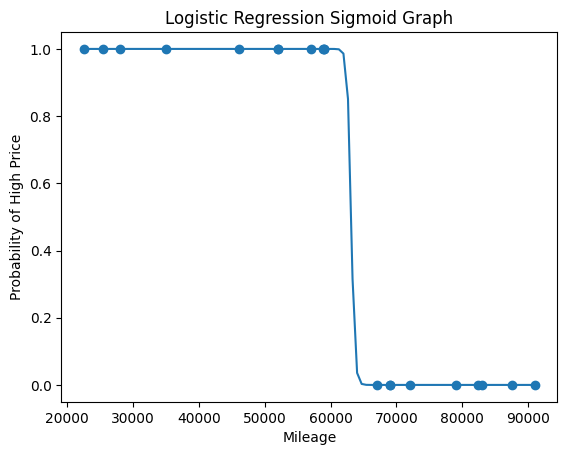

In [22]:
plt.scatter(X_graph, y_graph)
plt.plot(x_test, y_prob)
plt.xlabel("Mileage")
plt.ylabel("Probability of High Price")
plt.title("Logistic Regression Sigmoid Graph")
plt.show()